In [2]:
# shift of wavelength range by inspection
end=-1

import sys
# Temporarily add path for the current session
sys.path.append('/Users/coletamburri/Desktop/DKIST_Code/Flare_Patrol_Analysis/WORKING_SOURCE/')

# package initialize
import dkistpkg_ct as DKISTanalysis
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update(matplotlib.rcParamsDefault)

In [3]:
# color scheme for plotting
muted = DKISTanalysis.color_muted2()

# path and file ID for ViSP data
path = '/Volumes/ViSP_External/pid_3_37/'
#folder2 = 'HSBDOY'  #What is QS file

data_folder_arm1 = 'MAFMDS' #calcium II h/h epsilon
data_folder_arm2 = 'TXYDCV' #h-alpha
data_folder_arm3 = 'YEZWFH' #Na I

In [4]:
arm1_data = DKISTanalysis.pathdef(path,data_folder_arm1)
arm2_data = DKISTanalysis.pathdef(path,data_folder_arm2)
arm3_data = DKISTanalysis.pathdef(path,data_folder_arm3)

In [6]:
caII_low = 570
caII_high = 775

halpha_low = 0
halpha_high = -1

halpha_low = 0
halpha_high = -1


# Stonyhurst lon/lat position of the AR from JHv - need to correct
lon = 0 #degrees
lat = 0 #degrees

lonqs = 0
latqs = 0


wl1 = 396.847 # central wavelength, Ca II H
wl2 = 656.3 # central wavelength, H-alpha
wl3 = 589.0 # central wavelength, Na I D2

In [126]:
# spatial coordinates
hpc1_arcsec1, hpc2_arcsec1, x_center1, y_center1, z1, rho1, mu1, doppshrel1,\
    doppshnonrel1 = \
    DKISTanalysis.spatialinit(path,data_folder_arm1,arm1_data,lon,lat,wl1)

# get limb darkening coefficient 
clv_corr1 = DKISTanalysis.limbdarkening(wl1, mu=mu1, nm=True)
    # for Ca II H (require mu value for determination, be sure to specify
    # correct wl units)

hpc1_arcsec2, hpc2_arcsec2, x_center2, y_center2, z2, rho2, mu2, doppshrel2,\
    doppshnonrel1 = \
    DKISTanalysis.spatialinit(path,data_folder_arm2,arm2_data,lon,lat,wl2)

# get limb darkening coefficient 
clv_corr2 = DKISTanalysis.limbdarkening(wl2, mu=mu2, nm=True)
    # for Ca II H (require mu value for determination, be sure to specify
    # correct wl units)

hpc1_arcsec3, hpc2_arcsec3, x_center3, y_center3, z3, rho3, mu3, doppshrel3,\
    doppshnonrel3 = \
    DKISTanalysis.spatialinit(path,data_folder_arm3,arm3_data,lon,lat,wl3)

# get limb darkening coefficient 
clv_corr3 = DKISTanalysis.limbdarkening(wl3, mu=mu3, nm=True)
    # for Ca II H (require mu value for determination, be sure to specify
    # correct wl units)
    
# time step start for chosen QS observations
startstep=0#where does interesting bit begin?
endstep=2000#where does interesting bit end?

In [127]:
times1[350]

'2025-06-02T21:43:11.405660'

In [ ]:
image_data_arr1, rasterpos1, times1 = \
    DKISTanalysis.multistepprocess(path,data_folder_arm1,arm1_data,startstep=startstep,div=1,endstep=endstep)

image_data_arr2, rasterpos2, times2 = \
    DKISTanalysis.multistepprocess(path,data_folder_arm2,arm2_data,startstep=startstep,div=1,endstep=endstep)

image_data_arr3, rasterpos3, times3 = \
    DKISTanalysis.multistepprocess(path,data_folder_arm3,arm3_data,startstep=startstep,div=1,endstep=endstep)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [17]:
np.shape(image_data_arr2)

(199, 908, 2548)

In [100]:
mean1 = np.nanmean(image_data_arr1,1)
mean2 = np.nanmean(image_data_arr2,1)
mean3 = np.nanmean(image_data_arr3,1)



/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_71345/3070149774.py:1: RuntimeWarning: Mean of empty slice
  mean1 = np.nanmean(image_data_arr1,1)
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_71345/3070149774.py:2: RuntimeWarning: Mean of empty slice
  mean2 = np.nanmean(image_data_arr2,1)
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_71345/3070149774.py:3: RuntimeWarning: Mean of empty slice
  mean3 = np.nanmean(image_data_arr3,1)


In [108]:
cent0 = image_data_arr1[:,460,:]
cent1 = image_data_arr1[:,630,:]
cent2 = image_data_arr2[:,440,:]
cent3 = image_data_arr3[:,175,:]

In [61]:
red1 = image_data_arr1[:,int(np.shape(image_data_arr1)[1])//2+200,:]
red2 = image_data_arr2[:,int(np.shape(image_data_arr2)[1])//2+200,:]
red3 = image_data_arr3[:,int(np.shape(image_data_arr3)[1])//2+200,:]

In [67]:
blue1 = image_data_arr1[:,int(np.shape(image_data_arr1)[1])//2-200,:]
blue2 = image_data_arr2[:,int(np.shape(image_data_arr2)[1])//2-200,:]
blue3 = image_data_arr3[:,int(np.shape(image_data_arr3)[1])//2-200,:]

[]

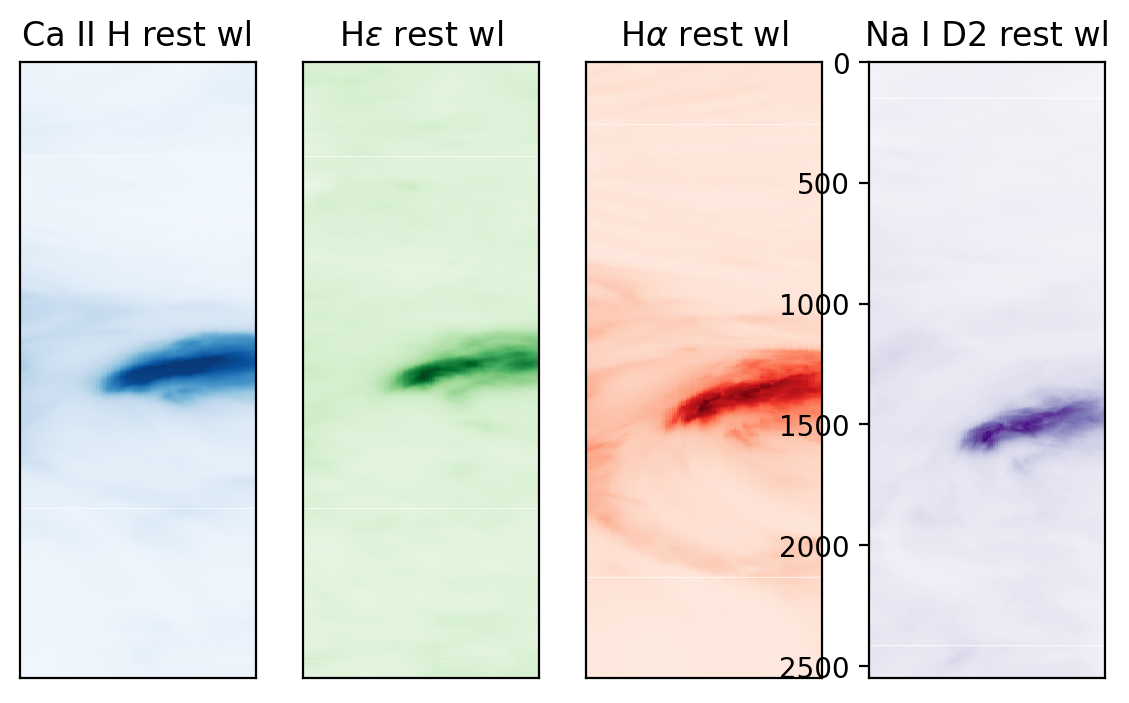

In [114]:
fig,ax=plt.subplots(1,4,dpi=200,figsize=(7,4));
ax.flatten()[0].pcolormesh(np.transpose(cent0[300:399]),cmap='Blues')
ax.flatten()[1].pcolormesh(np.transpose(cent1[300:399]),cmap='Greens')
ax.flatten()[2].pcolormesh(np.transpose(cent2[300:399]),cmap='Reds')
ax.flatten()[3].pcolormesh(np.transpose(cent3[300:399]),cmap='Purples')

ax.flatten()[0].invert_yaxis()
ax.flatten()[1].invert_yaxis()
ax.flatten()[2].invert_yaxis()
ax.flatten()[3].invert_yaxis()

ax.flatten()[0].set_title('Ca II H rest wl')
ax.flatten()[1].set_title(r'H$\epsilon$ rest wl')
ax.flatten()[2].set_title(r'H$\alpha$ rest wl')
ax.flatten()[3].set_title('Na I D2 rest wl')

ax.flatten()[0].set_xticks([])
ax.flatten()[1].set_xticks([])
ax.flatten()[2].set_xticks([])
ax.flatten()[3].set_xticks([])

ax.flatten()[0].set_yticks([])
ax.flatten()[1].set_yticks([])
ax.flatten()[2].set_yticks([])
ax.flatten()[3].set_xticks([])


[]

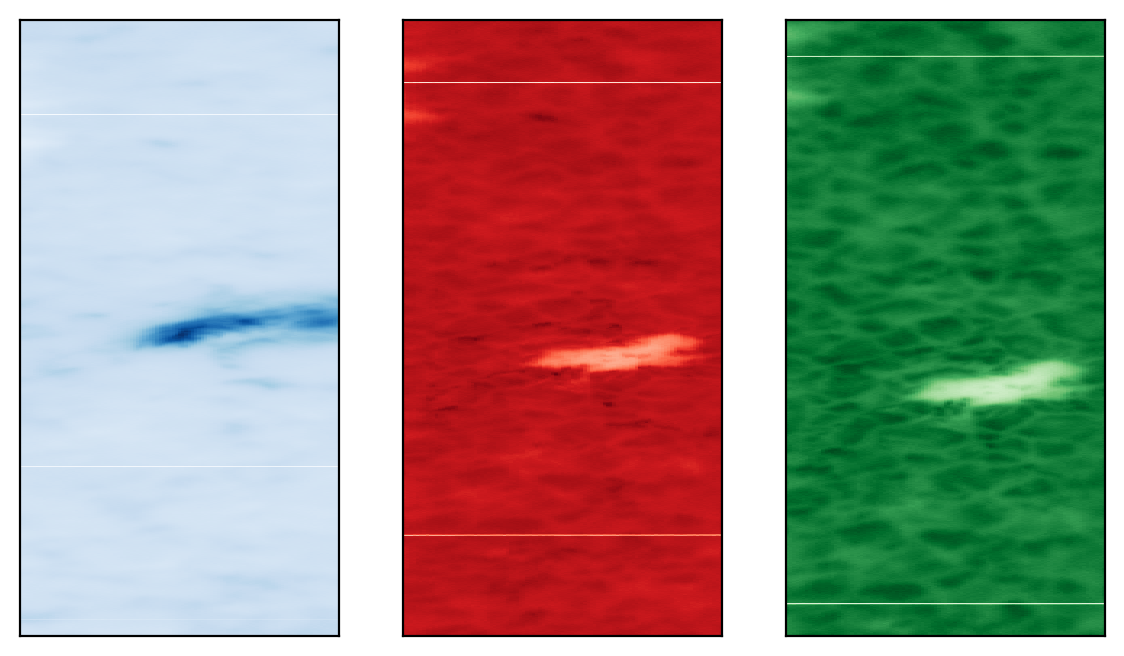

In [63]:
fig,ax=plt.subplots(1,3,dpi=200,figsize=(7,4));
ax.flatten()[0].pcolormesh(np.transpose(red1[300:399]),cmap='Blues')
ax.flatten()[1].pcolormesh(np.transpose(red2[300:399]),cmap='Reds')
ax.flatten()[2].pcolormesh(np.transpose(red3[300:399]),cmap='Greens')

ax.flatten()[0].invert_yaxis()
ax.flatten()[1].invert_yaxis()
ax.flatten()[2].invert_yaxis()

ax.flatten()[0].set_xticks([])
ax.flatten()[1].set_xticks([])
ax.flatten()[2].set_xticks([])
ax.flatten()[0].set_yticks([])
ax.flatten()[1].set_yticks([])
ax.flatten()[2].set_yticks([])

[]

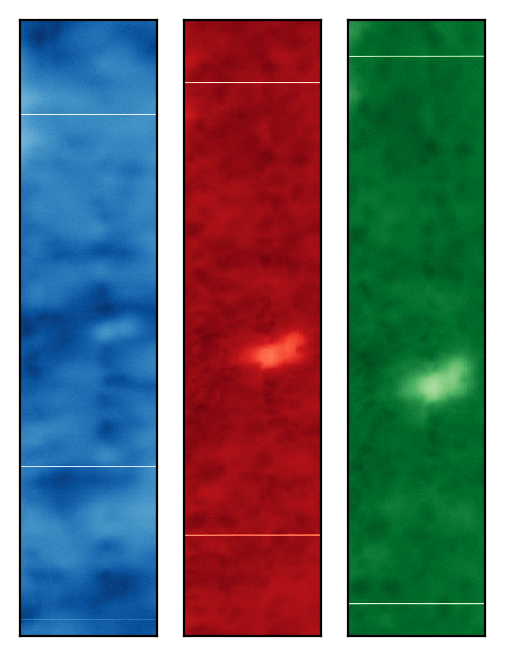

In [71]:
fig,ax=plt.subplots(1,3,dpi=200,figsize=(3,4));
ax.flatten()[0].pcolormesh(np.transpose(blue1[100:199]),cmap='Blues')
ax.flatten()[1].pcolormesh(np.transpose(blue2[100:199]),cmap='Reds')
ax.flatten()[2].pcolormesh(np.transpose(blue3[100:199]),cmap='Greens')

ax.flatten()[0].invert_yaxis()
ax.flatten()[1].invert_yaxis()
ax.flatten()[2].invert_yaxis()

ax.flatten()[0].set_xticks([])
ax.flatten()[1].set_xticks([])
ax.flatten()[2].set_xticks([])
ax.flatten()[0].set_yticks([])
ax.flatten()[1].set_yticks([])
ax.flatten()[2].set_yticks([])

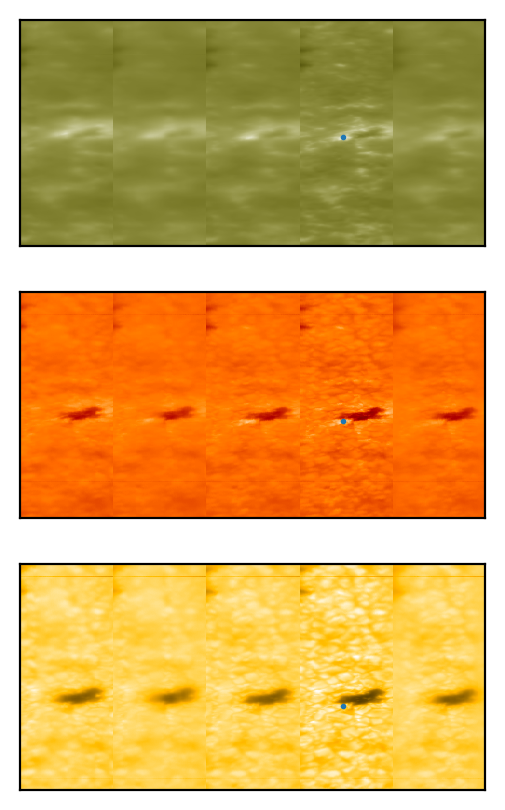

In [90]:
fig,ax=plt.subplots(3,1,dpi=200,figsize=(3,5));
ax.flatten()[0].pcolormesh(np.transpose(mean1),cmap='sdoaia1600')
ax.flatten()[1].pcolormesh(np.transpose(mean2),cmap='sdoaia304')
ax.flatten()[2].pcolormesh(np.transpose(mean3),cmap='sdoaia171')

ax.flatten()[0].invert_yaxis()
ax.flatten()[1].invert_yaxis()
ax.flatten()[2].invert_yaxis()

ax.flatten()[0].set_xticks([])
ax.flatten()[1].set_xticks([])
ax.flatten()[2].set_xticks([])
ax.flatten()[0].set_yticks([])
ax.flatten()[1].set_yticks([])
ax.flatten()[2].set_yticks([])

ax.flatten()[0].scatter([347],[1320],1)
ax.flatten()[1].scatter([347],[1455],1)
ax.flatten()[2].scatter([347],[1600],1)

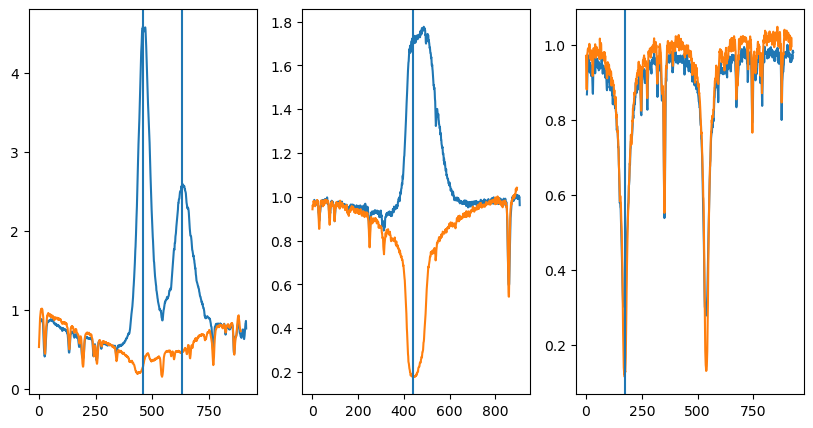

In [107]:
fig,ax=plt.subplots(1,3,figsize=(10,5))
ax.flatten()[0].plot(image_data_arr1[347,:,1320])
ax.flatten()[0].plot(image_data_arr1[347,:,-10])
ax.flatten()[1].plot(image_data_arr2[347,:,1455])
ax.flatten()[1].plot(image_data_arr2[347,:,-10])
ax.flatten()[2].plot(image_data_arr3[347,:,1600])
ax.flatten()[2].plot(image_data_arr3[347,:,-10])
ax.flatten()[0].axvline(460)
ax.flatten()[0].axvline(630)
ax.flatten()[1].axvline(440)
ax.flatten()[2].axvline(175)

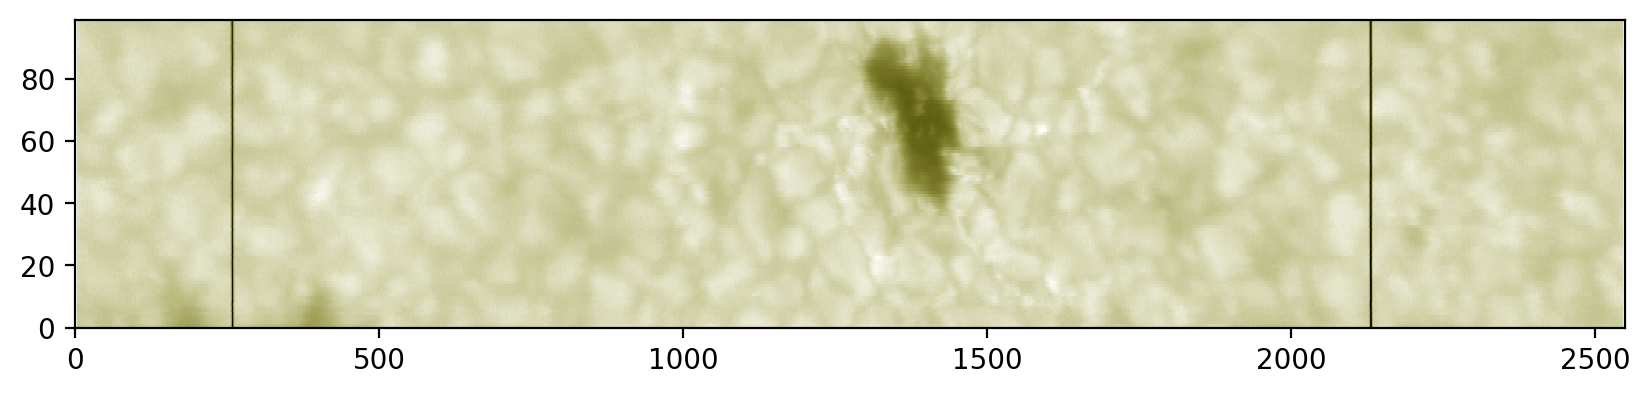

In [124]:
fig,ax=plt.subplots(dpi=200,figsize=(10,2))
ax.pcolormesh(image_data_arr2[300:399,50,:],cmap='sdoaia1600')

In [125]:
times1[300:399]

['2025-06-02T21:43:08.897615',
 '2025-06-02T21:43:08.947776',
 '2025-06-02T21:43:08.997937',
 '2025-06-02T21:43:09.048098',
 '2025-06-02T21:43:09.098259',
 '2025-06-02T21:43:09.148419',
 '2025-06-02T21:43:09.198580',
 '2025-06-02T21:43:09.248741',
 '2025-06-02T21:43:09.298902',
 '2025-06-02T21:43:09.349063',
 '2025-06-02T21:43:09.399224',
 '2025-06-02T21:43:09.449385',
 '2025-06-02T21:43:09.499546',
 '2025-06-02T21:43:09.549707',
 '2025-06-02T21:43:09.599868',
 '2025-06-02T21:43:09.650028',
 '2025-06-02T21:43:09.700189',
 '2025-06-02T21:43:09.750350',
 '2025-06-02T21:43:09.800511',
 '2025-06-02T21:43:09.850672',
 '2025-06-02T21:43:09.900833',
 '2025-06-02T21:43:09.950994',
 '2025-06-02T21:43:10.001155',
 '2025-06-02T21:43:10.051316',
 '2025-06-02T21:43:10.101477',
 '2025-06-02T21:43:10.151637',
 '2025-06-02T21:43:10.201798',
 '2025-06-02T21:43:10.251959',
 '2025-06-02T21:43:10.302120',
 '2025-06-02T21:43:10.352281',
 '2025-06-02T21:43:10.402442',
 '2025-06-02T21:43:10.452603',
 '2025-0